In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/CIFAR-10-images-master/train /content/train
!cp -r /content/drive/MyDrive/CIFAR-10-images-master/test /content/test

Mounted at /content/drive


In [ ]:
import torch # Libraries handle the tensors, neural networks, AdamW optimizer, data aug, data loaders, and ResNet-18 model
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision import models
import time
# Failsafe of VRAM runs out, defaults to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using: ", device)

Using:  cuda


In [ ]:
# Data Augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Methodology behind this is to take a random crop of each image, flip each image to double dataset, transform to tensor, and center to CIFAR-10 dataset size
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                        (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                        (0.2023, 0.1994, 0.2010))
])

In [ ]:
training_set = datasets.CIFAR10(root='/content/train', train=True, download=False, transform=transform_train)
testing_set = datasets.CIFAR10(root='/content/test', train=False, download=False, transform=transform_test)

In [ ]:
train_loader = DataLoader(training_set, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(testing_set, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
class LabelSmoothingCrossEntropy(nn.Module):
  def __init__(self, smoothing=0.1): # Label smoothing of 0.1 to prevent overfitting
    super(LabelSmoothingCrossEntropy, self).__init__()
    self.smoothing = smoothing
    self.confidence = 1.0 - smoothing

  def forward(self, x, target):
    logprobs = torch.nn.functional.log_softmax(x, dim=-1)
    nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
    smooth_loss = -logprobs.mean(dim=-1)
    loss = self.confidence * nll_loss + self.smoothing * smooth_loss
    return loss.mean()
criterion = LabelSmoothingCrossEntropy(smoothing=0.5)

In [ ]:
def get_cifar_resnet18():
    net = models.resnet18(weights=None) # Set weights to none
    net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False) # Stride of 1 to prevent skipping pixels
    net.maxpool = nn.Identity() # Deletes Resnet-18 maxpool to prevent data loss early
    net.fc = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(512, 10)
    )
    return net

model = get_cifar_resnet18().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.01)
optimizer = optim.AdamW(model.parameters(), lr=0.1, weight_decay=1e-4) # AdamW optimizer to adjust weights, high learning rate with cosinusoidal annealing to settle into a local minimum
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

In [ ]:
for epoch in range(50):
    model.train()
    total_loss, correct, total = 0, 0, 0
    start_time = time.time()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() # Resets the gradients every round, calculates neuron error, and adjusts weights of the neurons based on error
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()
    acc = 100. * correct / total
    print(f"Epoch {epoch+1}: Loss {total_loss/len(train_loader):.3f} | Acc {acc:.2f}% | Time {time.time()-start_time:.1f}s")

Epoch 1: Loss 1.583 | Acc 49.98% | Time 40.2s
Epoch 2: Loss 1.200 | Acc 69.23% | Time 39.9s
Epoch 3: Loss 1.044 | Acc 76.47% | Time 42.8s
Epoch 4: Loss 0.952 | Acc 80.42% | Time 42.6s
Epoch 5: Loss 0.893 | Acc 83.21% | Time 42.6s
Epoch 6: Loss 0.848 | Acc 85.32% | Time 42.6s
Epoch 7: Loss 0.808 | Acc 86.93% | Time 42.5s
Epoch 8: Loss 0.785 | Acc 87.99% | Time 42.7s
Epoch 9: Loss 0.754 | Acc 89.37% | Time 42.8s
Epoch 10: Loss 0.737 | Acc 89.89% | Time 42.9s
Epoch 11: Loss 0.720 | Acc 90.77% | Time 42.9s
Epoch 12: Loss 0.698 | Acc 91.81% | Time 42.7s
Epoch 13: Loss 0.684 | Acc 92.31% | Time 42.5s
Epoch 14: Loss 0.669 | Acc 92.99% | Time 42.5s
Epoch 15: Loss 0.653 | Acc 93.68% | Time 42.6s
Epoch 16: Loss 0.641 | Acc 94.24% | Time 42.5s
Epoch 17: Loss 0.629 | Acc 94.69% | Time 42.6s
Epoch 18: Loss 0.617 | Acc 95.17% | Time 42.7s
Epoch 19: Loss 0.607 | Acc 95.75% | Time 42.8s
Epoch 20: Loss 0.599 | Acc 96.06% | Time 42.8s
Epoch 21: Loss 0.588 | Acc 96.53% | Time 42.7s
Epoch 22: Loss 0.580 |

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(classification_report(all_labels, all_preds, target_names=training_set.classes))

              precision    recall  f1-score   support

    airplane       0.94      0.94      0.94      1000
  automobile       0.97      0.98      0.97      1000
        bird       0.91      0.90      0.91      1000
         cat       0.87      0.84      0.85      1000
        deer       0.92      0.95      0.93      1000
         dog       0.88      0.90      0.89      1000
        frog       0.95      0.95      0.95      1000
       horse       0.96      0.95      0.95      1000
        ship       0.96      0.97      0.96      1000
       truck       0.97      0.95      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



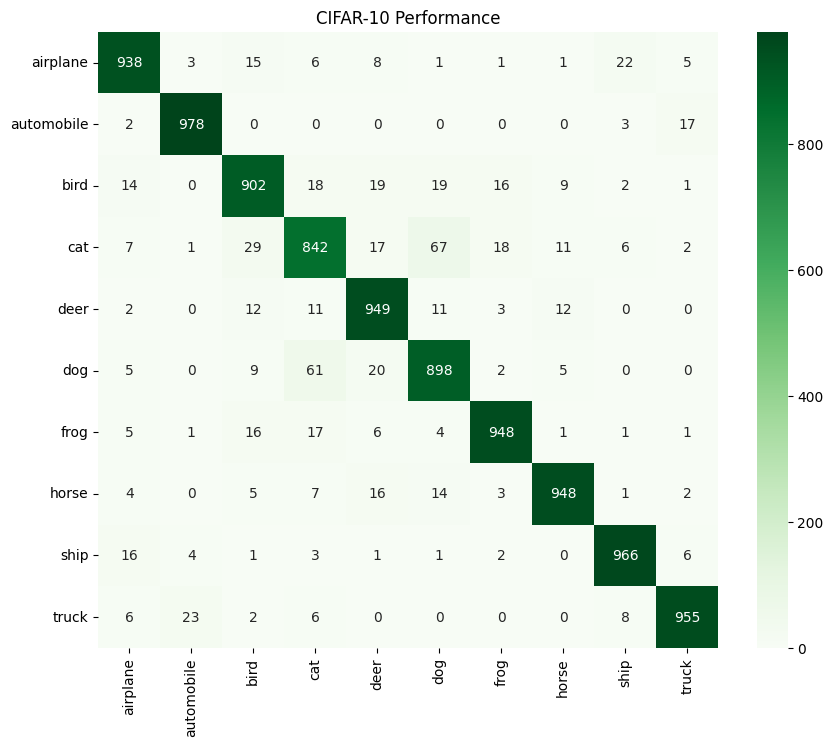

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=training_set.classes, yticklabels=training_set.classes)
plt.title("CIFAR-10 Performance")
plt.show()